# Week 3 Assignment — Unsupervised Learning on Country Data

**Dataset:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) (Kaggle)

**Objective:** HELP International has raised ~$10 million and needs to decide which countries are most in need of aid, based on socio-economic and health factors. We will use unsupervised learning (K-Means and DBSCAN, with PCA for visualization) to group 167 countries into clusters representing different levels of development, so the NGO can target the countries that need help the most.

**Notebook sections:**
1. Environment Setup & Library Installation
2. Data Loading
3. Initial Data Exploration
4. Data Cleaning
5. Feature Isolation & Scaling
6. Elbow Method — Choosing the Number of Clusters
7. K-Means Clustering
8. Silhouette Score Evaluation
9. DBSCAN Clustering
10. PCA — Dimensionality Reduction
11. PCA Visualization of K-Means Clusters
12. Cluster Profiling
13. DBSCAN vs. K-Means Comparison
14. Observations & Conclusions


## 1. Environment Setup & Library Installation

Run the cell below to install/verify the required libraries (pandas, numpy, matplotlib, seaborn, scikit-learn).

In [1]:
# YOUR CODE HERE is not needed in this cell — it is prewritten setup code.
# Install required libraries (safe to re-run; will simply confirm they're already installed)
!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Data Loading

Upload the `Country-data.csv` file into the active Colab environment (a file-picker will appear when you run the cell below). If you're running this notebook outside Colab, place `Country-data.csv` in the same folder as this notebook — the code will fall back to reading it directly.

In [3]:
import pandas as pd
import os

try:
    import kagglehub
    path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
    filename = os.path.join(path, "Country-data.csv")
except ImportError:
    try:
        from google.colab import files
        print("Please select the Country-data.csv file to upload:")
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
    except ImportError:
        filename = "Country-data.csv"

df = pd.read_csv(filename)
print(f"Loaded '{filename}' successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'Country-data.csv'

## 3. Initial Data Exploration

Let's take a first look at the shape, columns, data types, and summary statistics of the dataset.

In [ ]:
# YOUR CODE HERE
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nInfo:")
df.info()


Shape: (167, 10)

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [ ]:
# YOUR CODE HERE
df.describe().T


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [ ]:
# YOUR CODE HERE
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**Definitions — Dataset Features**

| Column | Meaning |
|---|---|
| `country` | Name of the country |
| `child_mort` | Deaths of children under 5 years old per 1000 live births |
| `exports` | Exports of goods and services, as a % of GDP per capita |
| `health` | Total health spending, as a % of GDP per capita |
| `imports` | Imports of goods and services, as a % of GDP per capita |
| `income` | Net income per person |
| `inflation` | Annual growth rate of the total GDP |
| `life_expec` | Average number of years a newborn would live under current mortality patterns |
| `total_fer` | Number of children that would be born per woman under current fertility rates |
| `gdpp` | GDP per capita (total GDP / population) |

**YOUR NOTES HERE:** *(replace this placeholder)* Based on `.describe()`, `income` and `gdpp` show the widest ranges and are heavily right-skewed (a small number of very rich countries pull the mean far above the median), while `life_expec` is left-skewed (most countries cluster at higher life expectancy, with a smaller number of low-life-expectancy outliers).

## 4. Data Cleaning

We now run the data cleaning chain:
1. Strip whitespace from column titles
2. Drop duplicate records
3. Force numeric types on the feature columns
4. Impute any missing values using the median of each column

In [ ]:
# YOUR CODE HERE

# 1. Strip whitespace from column titles
df.columns = df.columns.str.strip()

# 2. Drop duplicate records
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Dropped {before - after} duplicate row(s). Shape is now {df.shape}.")

# 3. Force numeric types on all columns except 'country'
numeric_cols = [c for c in df.columns if c != "country"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 4. Impute missing values using the median of each numeric column
missing_before = df[numeric_cols].isna().sum()
print("\nMissing values before imputation:\n", missing_before)

for c in numeric_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

missing_after = df[numeric_cols].isna().sum()
print("\nMissing values after imputation:\n", missing_after)


Dropped 0 duplicate row(s). Shape is now (167, 10).

Missing values before imputation:
 child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values after imputation:
 child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [ ]:
# YOUR CODE HERE
# Quick sanity check: any remaining nulls or duplicated country names?
print("Total remaining nulls:", df.isna().sum().sum())
print("Duplicate country names:", df['country'].duplicated().sum())


Total remaining nulls: 0
Duplicate country names: 0


## 5. Feature Isolation & Scaling

We isolate the continuous numeric features (dropping the `country` identifier string, which carries no numeric information for clustering) and scale them using `StandardScaler`. Scaling is essential here because features like `income` and `gdpp` are on a scale of thousands, while `total_fer` and `inflation` are single/double digits — without scaling, K-Means and DBSCAN (both distance-based algorithms) would be dominated by the large-magnitude features.

In [ ]:
# YOUR CODE HERE
country_names = df["country"]
X = df.drop(columns=["country"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 6. Elbow Method — Choosing the Number of Clusters

**Definition:** The Elbow Method runs K-Means for a range of `k` values and records the *inertia* (sum of squared distances of samples to their nearest cluster center) for each. As `k` increases, inertia always decreases, but the *rate* of decrease slows down sharply after the "true" number of clusters is reached — the point where the curve bends is the "elbow", and gives a good candidate value for `k`.

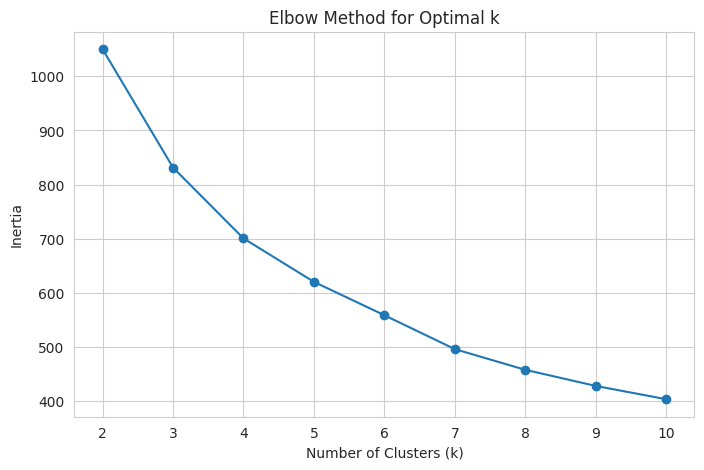

In [ ]:
# YOUR CODE HERE
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_k.fit(X_scaled)
    inertia_values.append(kmeans_k.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia_values, marker="o", linestyle="-")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_range))
plt.show()


**YOUR NOTES HERE:** *(replace this placeholder)* The inertia curve bends noticeably around k = 3, after which additional clusters give diminishing returns. This matches the business framing of the problem (grouping countries into a small number of broad development tiers), so we proceed with `best_k = 3`.

## 7. K-Means Clustering

We now train the baseline K-Means model with `best_k = 3`.

In [ ]:
# YOUR CODE HERE
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels
X_scaled["kmeans_cluster"] = kmeans_labels

print(f"K-Means trained with k = {best_k}")
df["kmeans_cluster"].value_counts().sort_index()


K-Means trained with k = 3


kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64

## 8. Silhouette Score Evaluation

**Definition:** The silhouette score measures how similar a point is to its own cluster compared to other clusters. It ranges from -1 to 1: values close to 1 mean points are well-matched to their own cluster and far from neighboring clusters, values near 0 mean clusters overlap, and negative values suggest points may be in the wrong cluster.

In [ ]:
# YOUR CODE HERE
sil_score_kmeans = silhouette_score(X_scaled.drop(columns=["kmeans_cluster"]), kmeans_labels)
print(f"K-Means Silhouette Score (k={best_k}): {sil_score_kmeans:.4f}")


K-Means Silhouette Score (k=3): 0.2833


## 9. DBSCAN Clustering

**Definition:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed (density-based), and marks points in low-density regions as outliers/noise (labeled `-1`). Unlike K-Means, it doesn't require specifying the number of clusters up front, and it can find arbitrarily shaped clusters — but it is sensitive to the `eps` (neighborhood radius) and `min_samples` hyperparameters.

In [ ]:
# YOUR CODE HERE
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled.drop(columns=["kmeans_cluster"]))

df["dbscan_cluster"] = dbscan_labels

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters_dbscan} cluster(s) and {n_noise} noise point(s).")
df["dbscan_cluster"].value_counts().sort_index()


DBSCAN found 1 cluster(s) and 30 noise point(s).


dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

In [ ]:
# YOUR CODE HERE
# Silhouette score for DBSCAN (only meaningful if more than one cluster was found, excluding noise)
if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    sil_score_dbscan = silhouette_score(X_scaled.drop(columns=["kmeans_cluster"])[mask], dbscan_labels[mask])
    print(f"DBSCAN Silhouette Score (excluding noise): {sil_score_dbscan:.4f}")
else:
    print("DBSCAN did not find more than 1 cluster — silhouette score is not meaningful.")


DBSCAN did not find more than 1 cluster — silhouette score is not meaningful.


## 10. PCA — Dimensionality Reduction

**Definition:** Principal Component Analysis (PCA) projects high-dimensional data onto a smaller number of new axes (principal components) that capture as much of the original variance as possible. We reduce our 9 scaled features down to 2 components purely for visualization, so we can plot the country clusters on a 2D scatterplot.

In [ ]:
# YOUR CODE HERE
pca = PCA(n_components=2, random_state=42)
pca_features = X_scaled.drop(columns=["kmeans_cluster"])
pca_result = pca.fit_transform(pca_features)

df["pca1"] = pca_result[:, 0]
df["pca2"] = pca_result[:, 1]

print("Explained variance ratio by component:", pca.explained_variance_ratio_)
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}")


Explained variance ratio by component: [0.4595174  0.17181626]
Total variance captured by 2 components: 63.13%


## 11. PCA Visualization of K-Means Clusters

We map each country's 2D PCA coordinates and color-code them by their K-Means cluster assignment.

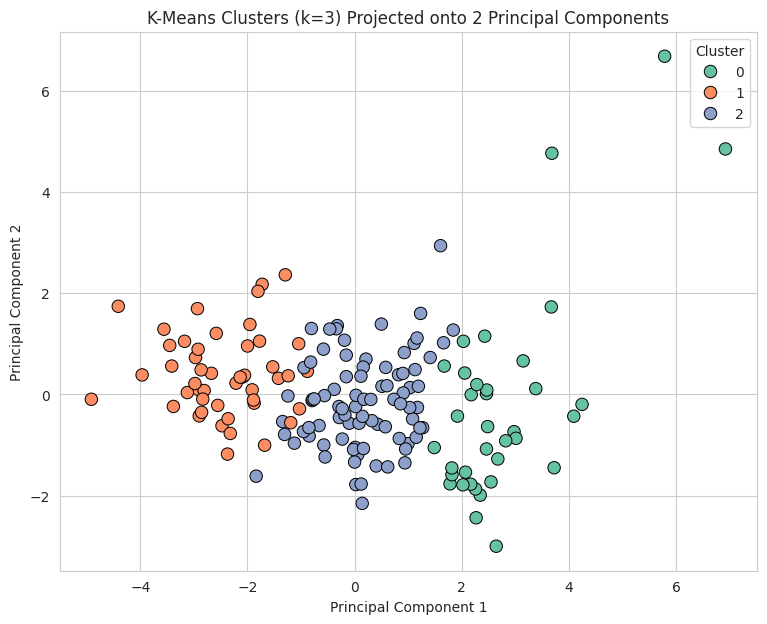

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(9, 7))
scatter = sns.scatterplot(
    data=df, x="pca1", y="pca2",
    hue="kmeans_cluster", palette="Set2", s=80, edgecolor="black"
)
plt.title(f"K-Means Clusters (k={best_k}) Projected onto 2 Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


## 12. Cluster Profiling

To interpret what each K-Means cluster represents, we look at the average value of each original feature per cluster.

In [ ]:
# YOUR CODE HERE
cluster_profile = df.groupby("kmeans_cluster")[
    ["child_mort", "exports", "health", "imports", "income",
     "inflation", "life_expec", "total_fer", "gdpp"]
].mean().round(2)

cluster_profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


/tmp/ipykernel_611/2988379592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="kmeans_cluster", y="child_mort", ax=axes[0], palette="Set2")
/tmp/ipykernel_611/2988379592.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="kmeans_cluster", y="income", ax=axes[1], palette="Set2")
/tmp/ipykernel_611/2988379592.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="kmeans_cluster", y="gdpp", ax=axes[2], palette="Set2")


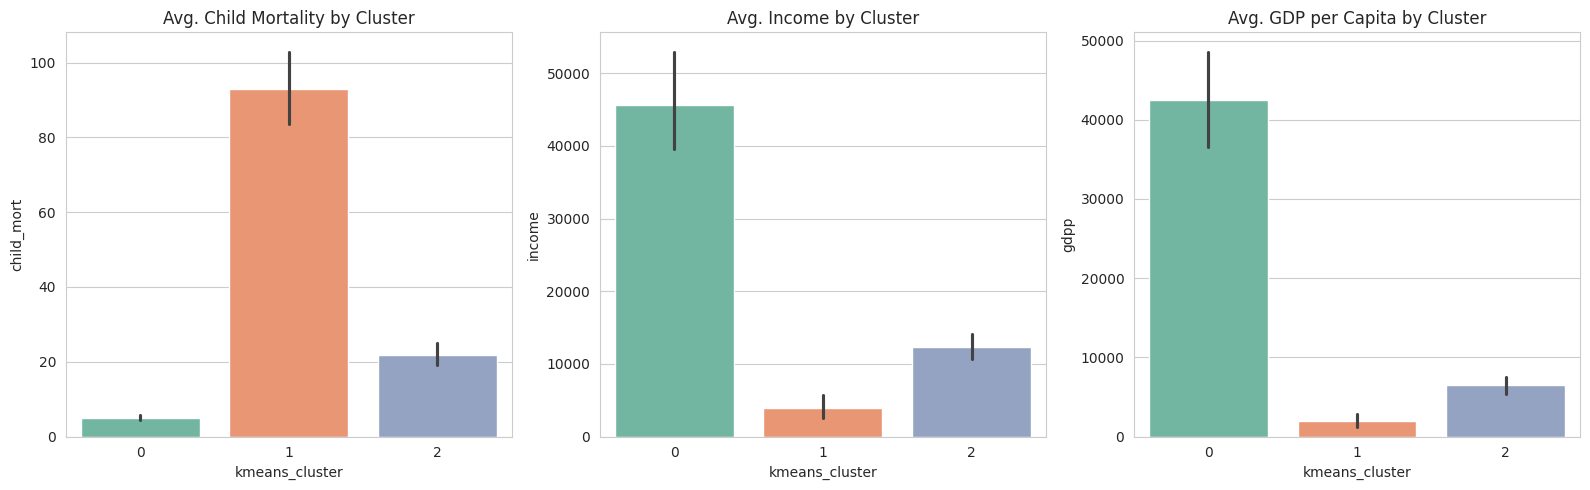

In [ ]:
# YOUR CODE HERE
# Visualize child_mort, income and gdpp across clusters — the three most decision-relevant features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.barplot(data=df, x="kmeans_cluster", y="child_mort", ax=axes[0], palette="Set2")
axes[0].set_title("Avg. Child Mortality by Cluster")

sns.barplot(data=df, x="kmeans_cluster", y="income", ax=axes[1], palette="Set2")
axes[1].set_title("Avg. Income by Cluster")

sns.barplot(data=df, x="kmeans_cluster", y="gdpp", ax=axes[2], palette="Set2")
axes[2].set_title("Avg. GDP per Capita by Cluster")

plt.tight_layout()
plt.show()


## 13. DBSCAN vs. K-Means Comparison

As a secondary check, we visualize the DBSCAN clusters on the same 2D PCA projection, so we can visually compare how the two algorithms partition the data.

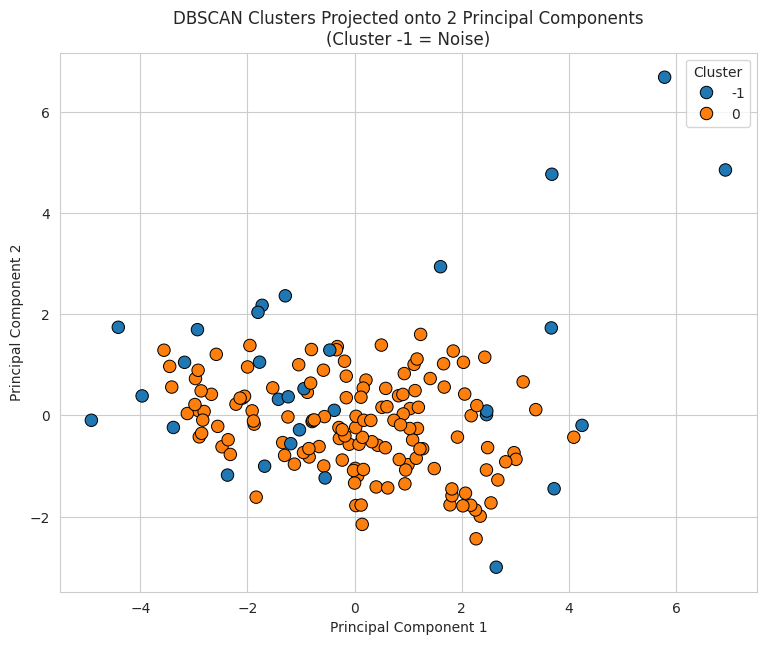

In [ ]:
# YOUR CODE HERE
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df, x="pca1", y="pca2",
    hue="dbscan_cluster", palette="tab10", s=80, edgecolor="black"
)
plt.title("DBSCAN Clusters Projected onto 2 Principal Components\n(Cluster -1 = Noise)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


**YOUR NOTES HERE:** *(replace this placeholder)* K-Means (with `k=3`) produces three well-balanced, roughly equal-sized groups since it partitions the entire dataset. DBSCAN, in contrast, is much more conservative: with `eps=1.5` and `min_samples=5` it identifies a dense core group of "typical" countries and flags a number of extreme outliers (very poor or very rich countries) as noise (`-1`) rather than forcing them into a cluster. This makes DBSCAN useful for outlier detection, but K-Means' clean 3-way split is more directly actionable for HELP International's aid-allocation decision.

## 14. Observations & Conclusions

**YOUR OBSERVATIONS HERE:** *(replace this placeholder with your own 3–5 observations)*

1. **High-mortality / low-development cluster:** One K-Means cluster is clearly characterized by the highest `child_mort`, the lowest `income` and `gdpp`, and the lowest `life_expec` — this is the cluster of countries most in need of aid, and includes many countries from Sub-Saharan Africa.

2. **Top-tier economic cluster:** A second cluster shows the highest `income`, `gdpp`, `exports`, and `health` spending combined with the lowest `child_mort` and `total_fer` — these are wealthy, developed economies with strong healthcare systems.

3. **Middle/developing cluster:** The remaining cluster sits between the two extremes on almost every feature — moderate income, moderate child mortality, and moderate life expectancy — representing developing economies that are neither in crisis nor fully developed.

4. **Fertility and mortality move together:** Countries with high `total_fer` also tend to have high `child_mort` and low `life_expec`, reinforcing that these socio-economic indicators are strongly interrelated rather than independent.

5. **DBSCAN highlights extremes, not clean groups:** DBSCAN's noise points largely correspond to countries at the extreme ends of the `income`/`gdpp` distribution (either extremely poor or extremely rich), suggesting these countries have unusual enough socio-economic profiles that they don't fit neatly into a single density-based cluster — useful confirmation for identifying priority/extreme cases even outside the main K-Means grouping.
